# Custom Compilers

The high-level functions `compile_logic` and `logic_to_loss` accept a `mode=` parameter
that selects the compilation strategy. The default is `mode='tnorm'`, which implements
logical operators using fuzzy t-norms. Within the t-norm family, several choices exist;
`mode='ltu'` selects a different strategy based on Linear Threshold Units.

By the end of this notebook, we will have seen:

1. How to select a compiler with `mode='tnorm'` or `mode='ltu'`, and how to pick a
   specific t-norm with the `tnorm=` parameter
2. How the strategies implement AND and OR differently
3. How compiler choice affects training on the `exactly_one` constraint from
   the [Semi-Supervised MNIST notebook](Semi-Supervised%20MNIST.ipynb)

## Preliminaries

To get started, let us first get the standard preambles out of the way.

In [61]:
%pip install torchvision -q -q

Note: you may need to restart the kernel to use updated packages.


In [62]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, TensorDataset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import pysignet as psn

## The compiler API

The only difference between using a TNorm compiler and an LTU compiler is the `mode=`
argument, and, for LTU, the optional `alpha=` sharpness parameter.
The expression, the predicates, and the training loop are unchanged.

```python
# Default: MixedTNorm
constraint = psn.logic_to_loss(expr, predicates)

# Specific t-norm:
constraint = psn.logic_to_loss(expr, predicates, tnorm=psn.GodelTNorm())

# LTU compiler:
constraint = psn.logic_to_loss(expr, predicates, mode='ltu', alpha=2.0)
```

The same `mode=` parameter works for `compile_logic`.
The `alpha` parameter controls how sharply the LTU's sigmoid gates fire:
with `alpha=1` the gate is soft; with larger values it approaches a hard threshold.

## How AND and OR differ

Both compilers map logical operators to smooth functions of predicate values in [0, 1].
For AND applied to n inputs with values v_1, ..., v_n:

| Compiler | AND formula |
|---|---|
| TNorm (RProduct) | v_1 * v_2 * ... * v_n |
| TNorm (Godel) | min(v_1, ..., v_n) |
| LTU | sigmoid(alpha * (v_1 + ... + v_n - (n - 0.5))) |

For OR the threshold drops to 0.5: the sum only needs to exceed a single fully-active input.

The LTU's AND threshold is `n - 0.5`: the sum of all inputs must be nearly as large as
the maximum possible sum `n`. This is a counting criterion; all inputs must contribute.
T-norms use a different geometry: RProduct multiplies, which is sensitive to any single
near-zero input; Godel takes the minimum, which is sparse but exact.

The code below plots `And(P(X), Q(X))` when `P` and `Q` both output the same value `v`,
sweeping `v` from 0 to 1.

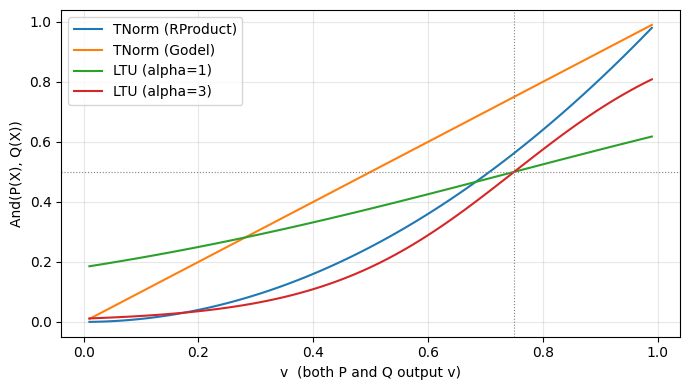

In [63]:
P, Q = psn.Symbol("P Q")
X = psn.Variable("X")
and_expr = psn.And(P(X), Q(X))

v = torch.linspace(0.01, 0.99, 100)
pred = {"P": lambda x: x, "Q": lambda x: x}

compilers = {
    "TNorm (RProduct)": psn.compile_logic(and_expr, pred, tnorm=psn.RProductTNorm()),
    "TNorm (Godel)":    psn.compile_logic(and_expr, pred, tnorm=psn.GodelTNorm()),
    "LTU (alpha=1)":    psn.compile_logic(and_expr, pred, mode="ltu", alpha=1.0),
    "LTU (alpha=3)":    psn.compile_logic(and_expr, pred, mode="ltu", alpha=3.0),
}

fig, ax = plt.subplots(figsize=(7, 4))
for name, compiled in compilers.items():
    with torch.no_grad():
        y = compiled(X=v)
    ax.plot(v.numpy(), y.numpy(), label=name)

ax.axhline(0.5, color="gray", linestyle=":", linewidth=0.8)
ax.axvline(0.75, color="gray", linestyle=":", linewidth=0.8)
ax.set_xlabel("v  (both P and Q output v)")
ax.set_ylabel("And(P(X), Q(X))")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

RProduct squares the value: `And(0.7, 0.7) = 0.49`. Godel is the identity on equal inputs:
`And(0.7, 0.7) = 0.7`. LTU crosses 0.5 at `v = 0.75`, the point where the sum `2v = 1.5 = n - 0.5`
for `n = 2`. Larger `alpha` makes the crossover sharper.

The vertical dotted line at `v = 0.75` marks the LTU threshold: below it, `And` is less
than 0.5; above it, greater than 0.5. Unlike RProduct and Godel, both of which are above 0.5
for `v = 0.7`, LTU considers two 0.7-confidence inputs not yet jointly satisfied.

## The `exactly_one` constraint on MNIST

We revisit the semi-supervised MNIST setting from the
[Semi-Supervised MNIST notebook](Semi-Supervised%20MNIST.ipynb). The setup is identical:
50 labeled examples, 5000 unlabeled examples, and the `exactly_one` constraint applied
as an unsupervised penalty on the unlabeled data. The only change is the `mode=` argument
to `logic_to_loss`.

In [64]:
Digit = psn.Symbol("Digit")
X, Y = psn.Variable("X Y")
I, J = psn.Variable("I J")

at_least_one = psn.Exists(Y, range(10), Digit(X, Y))
at_most_one  = psn.ForAll([I, J],
                           [(i, j) for i in range(10) for j in range(i + 1, 10)],
                           psn.Not(psn.And(Digit(X, I), Digit(X, J))))
exactly_one  = psn.And(at_least_one, at_most_one)

In [65]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
    transforms.Lambda(lambda x: x.view(-1)),
])

train_dataset = datasets.MNIST("./data", train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST("./data", train=False, transform=transform)

torch.manual_seed(1)
indices           = torch.randperm(len(train_dataset))
labeled_dataset   = Subset(train_dataset, indices[:50])
unlabeled_dataset = Subset(train_dataset, indices[50:5050])

labeled_loader   = DataLoader(labeled_dataset,   batch_size=32,  shuffle=True)
unlabeled_loader = DataLoader(unlabeled_dataset,  batch_size=128, shuffle=True)
test_loader      = DataLoader(test_dataset,       batch_size=256, shuffle=False)

print(f"Labeled: {len(labeled_dataset)},  unlabeled: {len(unlabeled_dataset)},  test: {len(test_dataset)}")

Labeled: 50,  unlabeled: 5000,  test: 10000


In [66]:
class MNISTClassifier(nn.Module):
    def __init__(self, hidden_size: int = 256):
        super().__init__()
        self.fc1 = nn.Linear(784, hidden_size)
        self.fc2 = nn.Linear(hidden_size, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)


def evaluate(model: nn.Module, loader: DataLoader) -> float:
    checker = psn.consistency_report(Digit(X, Y), {"Digit": model})
    for x, y in loader:
        checker.eval(X=x, Y=y)
    return checker.global_consistency()

## Training

We run five variants on the same semi-supervised MNIST setup: a supervised baseline and
four constrained models, one per compiler strategy:

- **Supervised only**: cross-entropy on 50 labels, no constraint
- **Godel**: `GodelTNorm` (AND = min, OR = max)
- **RProduct**: `RProductTNorm` (AND = product, OR = probabilistic sum)
- **Lukasiewicz**: `LukasiewiczTNorm` (AND = max(0, a+b-1), OR = min(1, a+b))
- **LTU**: `mode='ltu'`, `alpha=2.0` (AND/OR as sigmoid of linear sum)

All four semi-supervised variants start from the same random weights (`torch.manual_seed(1)`)
and run for five epochs total (one warmup + four constrained).

In [67]:
def train_supervised(n_epochs: int = 5, lr: float = 0.001) -> list[float]:
    model = MNISTClassifier()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []
    for _ in range(n_epochs):
        model.train()
        for x, y in labeled_loader:
            optimizer.zero_grad()
            F.cross_entropy(model(x), y).backward()
            optimizer.step()
        history.append(evaluate(model, test_loader))
    return history


def train_semi_supervised(
    mode: str = "tnorm",
    tnorm: psn.TNorm | None = None,
    alpha: float = 1.0,
    n_epochs: int = 4,
    warmup_epochs: int = 1,
    lr: float = 0.001,
    constraint_weight: float = 0.01,
) -> list[float]:
    model = MNISTClassifier()
    constraint = psn.logic_to_loss(exactly_one, {"Digit": model},
                                   mode=mode, tnorm=tnorm, alpha=alpha)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []

    for _ in range(warmup_epochs):
        model.train()
        for x_l, y_l in labeled_loader:
            optimizer.zero_grad()
            F.cross_entropy(model(x_l), y_l).backward()
            optimizer.step()
        history.append(evaluate(model, test_loader))

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    for _ in range(n_epochs):
        model.train()
        unlabeled_iter = iter(unlabeled_loader)
        for x_l, y_l in labeled_loader:
            optimizer.zero_grad()
            ce_loss = F.cross_entropy(model(x_l), y_l)
            try:
                x_u, _ = next(unlabeled_iter)
            except StopIteration:
                unlabeled_iter = iter(unlabeled_loader)
                x_u, _ = next(unlabeled_iter)
            logic_loss = constraint.loss(X=x_u, quantify="none", reduction="mean")
            (ce_loss + constraint_weight * logic_loss).backward()
            optimizer.step()
        history.append(evaluate(model, test_loader))

    return history

In [72]:
torch.manual_seed(1)
history_supervised = train_supervised()
print("Supervised done")

torch.manual_seed(1)
history_godel = train_semi_supervised(tnorm=psn.GodelTNorm())
print("Godel done")

torch.manual_seed(1)
history_rproduct = train_semi_supervised(tnorm=psn.RProductTNorm())
print("RProduct done")

torch.manual_seed(1)
history_lukasiewicz = train_semi_supervised(tnorm=psn.LukasiewiczTNorm())
print("Lukasiewicz done")

torch.manual_seed(1)
history_ltu_1 = train_semi_supervised(mode="ltu", alpha=2.0)
print("LTU (alpha=1) done")

torch.manual_seed(1)
history_ltu_2 = train_semi_supervised(mode="ltu", alpha=2.0)
print("LTU (alpha=2) done")

torch.manual_seed(1)
history_ltu_20 = train_semi_supervised(mode="ltu", alpha=20.0)
print("LTU (alpha=20) done")

Supervised done
Godel done
RProduct done
Lukasiewicz done
LTU (alpha=1) done
LTU (alpha=2) done


/Users/vivek/Dropbox/workspace/pysignet/src/pysignet/compilation/ltu_compiler.py:62: UserWarning: Parameter alpha = 20.0 is too large and may lead to unreliable gradients. Consider using smaller alpha.
  warnings.warn(


LTU (alpha=20) done


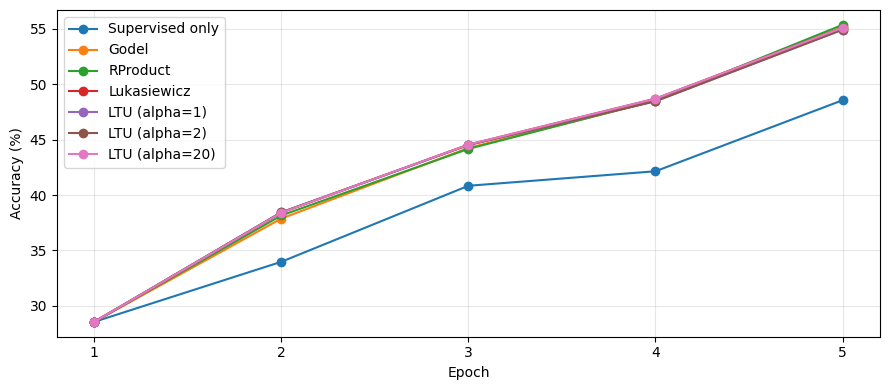

Final accuracy:
  Supervised only     : 0.4856
  Godel               : 0.5514
  RProduct            : 0.5536
  Lukasiewicz         : 0.5510
  LTU (alpha=1)       : 0.5493
  LTU (alpha=2)       : 0.5493
  LTU (alpha=20)      : 0.5510


In [73]:
epochs = range(1, 6)

fig, ax = plt.subplots(figsize=(9, 4))
for label, history in [
    ("Supervised only",  history_supervised),
    ("Godel",            history_godel),
    ("RProduct",         history_rproduct),
    ("Lukasiewicz",      history_lukasiewicz),
    ("LTU (alpha=1)",    history_ltu_1),
    ("LTU (alpha=2)",    history_ltu_2),
    ("LTU (alpha=20)",    history_ltu_20),
]:
    ax.plot(epochs, [a * 100 for a in history], marker="o", label=label)

ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy (%)")
ax.set_xticks(list(epochs))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Final accuracy:")
for label, history in [
    ("Supervised only",  history_supervised),
    ("Godel",            history_godel),
    ("RProduct",         history_rproduct),
    ("Lukasiewicz",      history_lukasiewicz),
    ("LTU (alpha=1)",    history_ltu_1),
    ("LTU (alpha=2)",    history_ltu_2),
    ("LTU (alpha=20)",    history_ltu_20),
]:
    print(f"  {label:20s}: {history[-1]:.4f}")

## Results

All four constrained variants improve over the supervised baseline (0.486) by roughly
6.5 percentage points. The three t-norms cluster tightly: RProduct (0.554), Godel (0.551),
and Lukasiewicz (0.551) are all within 0.3 percentage points of each other. LTU matches
this range too (0.549, 0.551).

The similarity across compilers reflects the structure of `exactly_one`. The constraint
is a conjunction of `at_least_one` (a 10-way disjunction over softmax outputs) and
`at_most_one` (45 pairwise terms). The 45-pair conjunction dominates the gradient signal
regardless of which compiler is used, which is why all four converge to similar performance.
The main practical reason to experiment with different compilers is when one strategy
provides noticeably better gradient flow for a specific expression structure. For example,
RProduct's residuum-based `Implies` behaves differently from Godel's hard min/max, which
can matter for formulas built around implication rather than conjunction.